In [27]:
import pandas as pd
import numpy as np

In [28]:
df = pd.read_csv("Risk_Alert.csv")

In [29]:
df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


In [30]:
df.drop(columns=["customer_id"], inplace=True)

In [31]:
df.shape

(4600, 18)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        4460 non-null   float64
 1   gender                     4600 non-null   str    
 2   region                     4498 non-null   str    
 3   employment_type            4456 non-null   str    
 4   annual_income_inr          4434 non-null   float64
 5   credit_score               4384 non-null   float64
 6   credit_utilization_ratio   4453 non-null   float64
 7   missed_payments_12m        4600 non-null   int64  
 8   avg_late_payment_days      4600 non-null   float64
 9   monthly_transaction_count  4600 non-null   int64  
 10  monthly_spend_inr          4471 non-null   float64
 11  cash_advance_count_6m      4600 non-null   int64  
 12  complaints_last_6m         4600 non-null   int64  
 13  failed_login_attempts_3m   4600 non-null   int64  
 14  acc

In [33]:
df.isnull().sum()

age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

In [34]:
cat_cols = df.select_dtypes(include=["object"]).columns
print("Categorical columns:", cat_cols)

Categorical columns: Index(['gender', 'region', 'employment_type', 'last_transaction_date'], dtype='str')


C:\Users\parth\AppData\Local\Temp\ipykernel_3436\939030578.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [35]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")

df[cat_cols] = imputer.fit_transform(df[cat_cols])

In [36]:
df.isnull().sum()

age                          140
gender                         0
region                         0
employment_type                0
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

In [37]:
from sklearn.impute import KNNImputer

In [38]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

imputer = KNNImputer(n_neighbors=5)

df[num_cols] = imputer.fit_transform(df[num_cols])

In [39]:
df.isnull().sum()

age                          0
gender                       0
region                       0
employment_type              0
annual_income_inr            0
credit_score                 0
credit_utilization_ratio     0
missed_payments_12m          0
avg_late_payment_days        0
monthly_transaction_count    0
monthly_spend_inr            0
cash_advance_count_6m        0
complaints_last_6m           0
failed_login_attempts_3m     0
account_tenure_months        0
last_transaction_date        0
debt_balance_inr             0
risk_status                  0
dtype: int64

In [41]:
import sweetviz as sv

report = sv.analyze(df)

                                             |          | [  0%]   00:00 -> (? left)

In [42]:
report.show_html('report.html')

Report report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [43]:

print(df.duplicated().sum())

0


In [44]:
numeric_cols = df.select_dtypes(include=['number']).columns

skewness = df[numeric_cols].skew()
print(skewness.sort_values(ascending=False))

avg_late_payment_days        2.730704
risk_status                  2.323751
missed_payments_12m          2.203966
complaints_last_6m           2.024082
cash_advance_count_6m        2.022959
debt_balance_inr             1.403744
monthly_spend_inr            1.301996
annual_income_inr            1.187706
account_tenure_months        1.098666
failed_login_attempts_3m     1.048311
credit_utilization_ratio     0.458255
age                          0.256785
monthly_transaction_count    0.044364
credit_score                -0.378358
dtype: float64


In [45]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

df[numeric_cols] = pt.fit_transform(df[numeric_cols])

In [46]:
numeric_cols = df.select_dtypes(include=['number']).columns

skewness = df[numeric_cols].skew()
print(skewness.sort_values(ascending=False))

risk_status                  2.323751
complaints_last_6m           0.690508
cash_advance_count_6m        0.338668
missed_payments_12m          0.235864
credit_utilization_ratio     0.017702
avg_late_payment_days        0.014186
credit_score                 0.007027
annual_income_inr           -0.002108
monthly_spend_inr           -0.002479
account_tenure_months       -0.012896
debt_balance_inr            -0.017556
failed_login_attempts_3m    -0.021867
age                         -0.029984
monthly_transaction_count   -0.032131
dtype: float64


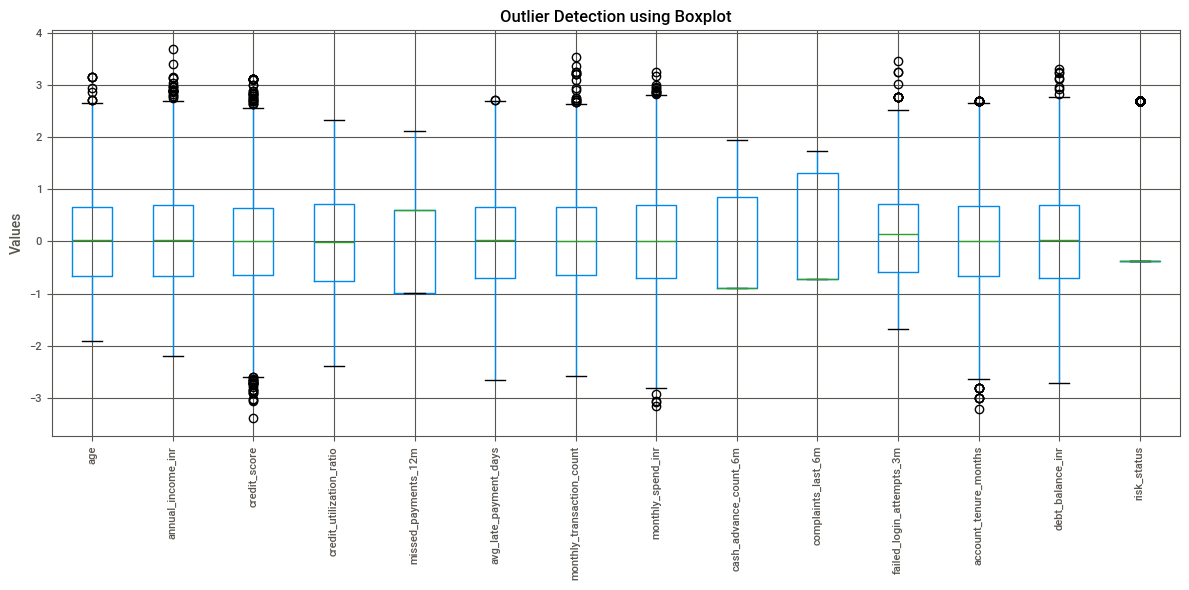

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot(rot=90)
plt.title("Outlier Detection using Boxplot")
plt.ylabel("Values")
plt.tight_layout()
plt.show()

In [48]:


Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[
    ~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
      (df[numeric_cols] > (Q3 + 1.5 * IQR)))
    .any(axis=1)
]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)


Original Shape: (4600, 18)
After Removing Outliers: (3938, 18)


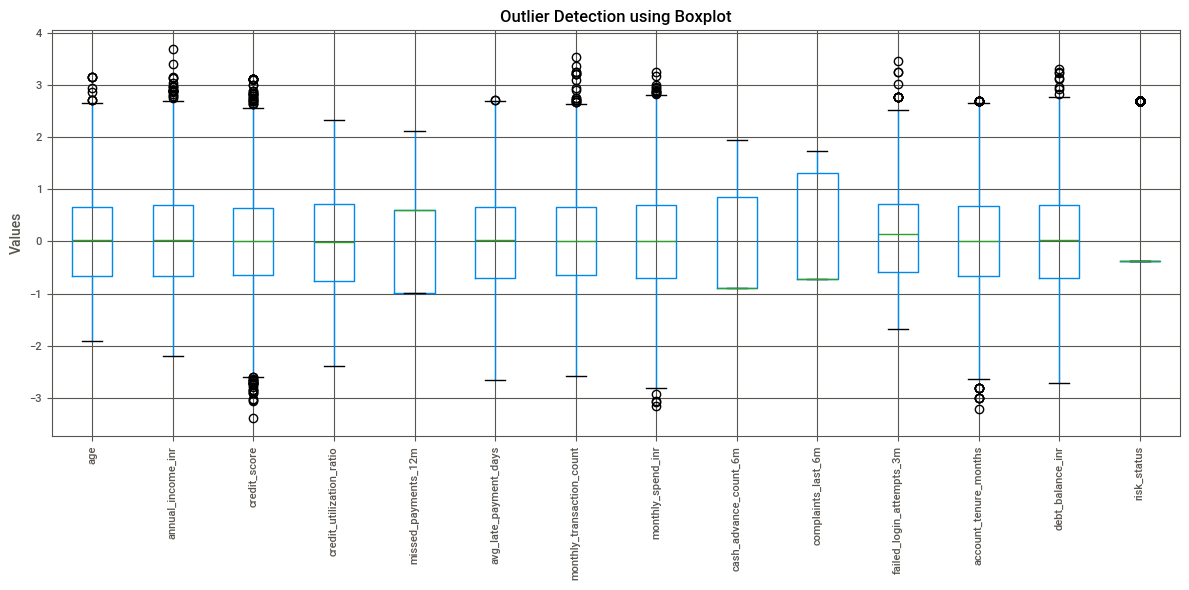

In [49]:
plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot(rot=90)
plt.title("Outlier Detection using Boxplot")
plt.ylabel("Values")
plt.tight_layout()
plt.show()

In [50]:
df_clean.to_csv("output.csv", index=False)